[69.14 30.86]


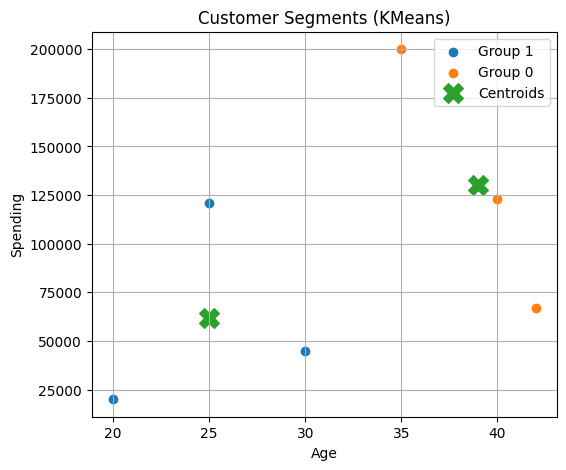

  Customer  Age  Spending  Group
0      ali   20     20000      1
1    zuban   30     45000      1
2     neha   35    200000      0
3    surha   40    123000      0
4     lela   42     67000      0
5     neon   25    121000      1


In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# sample data
data = {
    'Customer': ['ali','zuban','neha','surha','lela','neon'],
    'Age':['20','30','35','40','42','25'],
    'Spending':['20000','45000','200000','123000','67000','121000']
}

df = pd.DataFrame(data)

# convert to numeric
df['Age'] = pd.to_numeric(df['Age'])
df['Spending'] = pd.to_numeric(df['Spending'])

# features
X = df[['Age','Spending']]

# scaling (critical step)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca,columns=['Age','Spending'])
explain_variance =pca.explained_variance_ratio_ 
print(np.round(explain_variance*100,2))
# model
model = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Group'] = model.fit_predict(X_scaled)

# plot
plt.figure(figsize=(6,5))
for group in df['Group'].unique():
    group_data = df[df['Group']==group]
    plt.scatter(group_data['Age'], group_data['Spending'], label=f"Group {group}")

# plot centroids
centroids = scaler.inverse_transform(model.cluster_centers_)
plt.scatter(centroids[:,0], centroids[:,1], s=200, marker='X', label='Centroids')

plt.xlabel('Age')
plt.ylabel('Spending')
plt.title('Customer Segments (KMeans)')
plt.legend()
plt.grid(True)
plt.show()
print(df)
